# Coin-selection project
### Python

## Load libraries and simulation results

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'cyan',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'blue',
#    'RANDOM': 'magenta',
#    'MIN_BILLS': 'blue',
#    'EVEN_FROM_MIN_TO_MAX': 'red',
#    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'WALLET_CORE': 'green',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
    'CALL_EXTERNAL': 'black'
}

# Initialize an empty list to hold all data
all_data = []

# Process each file
for file_name in files:
    print(file_name)
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        user_type, strategy = file.readline().strip().split(', ')
        
        # Parse the rest of the data
        for line in file:
            id, time, amount, operation, fee, *_ = line.strip().split(', ')  # Updated here to include 'amount'
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name  
            })

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)

# Filter out DEPOSIT_REFRESH_OP right away
df = df[(df['Operation'] != 'DEPOSIT_REFRESH_OP') & (df['Amount'] > 0)] # removed "& (df['Amount'] < 500000)" here

df.describe()

user_0_strategy_WALLET_CORE.csv
user_0_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_0_strategy_GREEDY_MIN_TO_MAX.csv
user_0_strategy_CALL_EXTERNAL.csv


,Time,Amount,Fee
count,5.282000e+03,5.282000e+03,5282.000000
mean,4.678503e+07,2.521828e+05,3.652215
std,2.705497e+07,5.104871e+05,6.664351
min,4.320000e+05,5.230000e+03,1.000000
25%,2.291760e+07,1.772400e+04,1.000000
50%,4.682880e+07,2.163500e+04,1.000000
75%,7.032960e+07,2.778200e+04,6.000000
max,9.322560e+07,1.999937e+06,208.000000


## Generate cumulative fee for each user over time

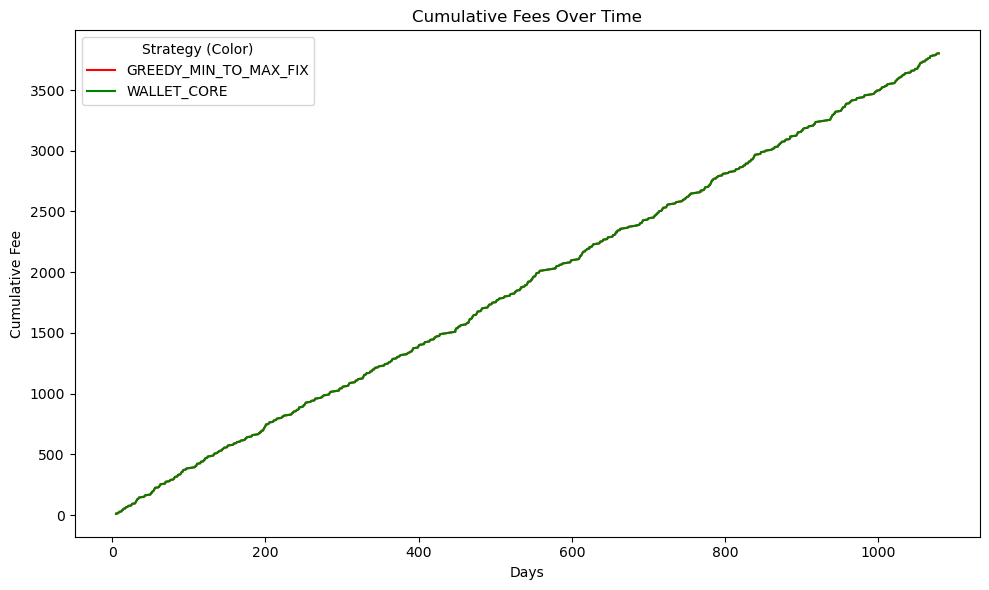

In [3]:
### Create a plot for each user type
for user_type in df['UserType'].unique():
    plt.figure(figsize=(10, 6))
    user_type_df = df[df['UserType'] == user_type]

    # Plot cumulative fee for each user's data
    for file_name, user_df in user_type_df.groupby('FileName'):
        strategy = user_df['Strategy'].iloc[0]  # Strategy is the same for all rows of this user
        if strategy not in strategy_colors:
            continue
        user_df = user_df.sort_values('Time').reset_index()
        user_df['CumulativeFee'] = user_df['Fee'].cumsum()
        user_df['Days'] = user_df['Time']/3600/24
        plt.plot(user_df['Days'], user_df['CumulativeFee'], label=strategy, color=strategy_colors[strategy])

    # Enhancing the plot
    plt.title(f"Cumulative Fees Over Time")
    plt.xlabel("Days")
    plt.ylabel("Cumulative Fee")
    plt.tight_layout()

    # Adding legend with color description
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='Strategy (Color)')

    # Save the plot
    plt.savefig(f"pictures/{user_type}_cumulative_fees.png", bbox_inches='tight', dpi=300)
    plt.show()

## Plot cummulative fees, for all users/ strategies

/tmp/ipykernel_44686/2161657711.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers


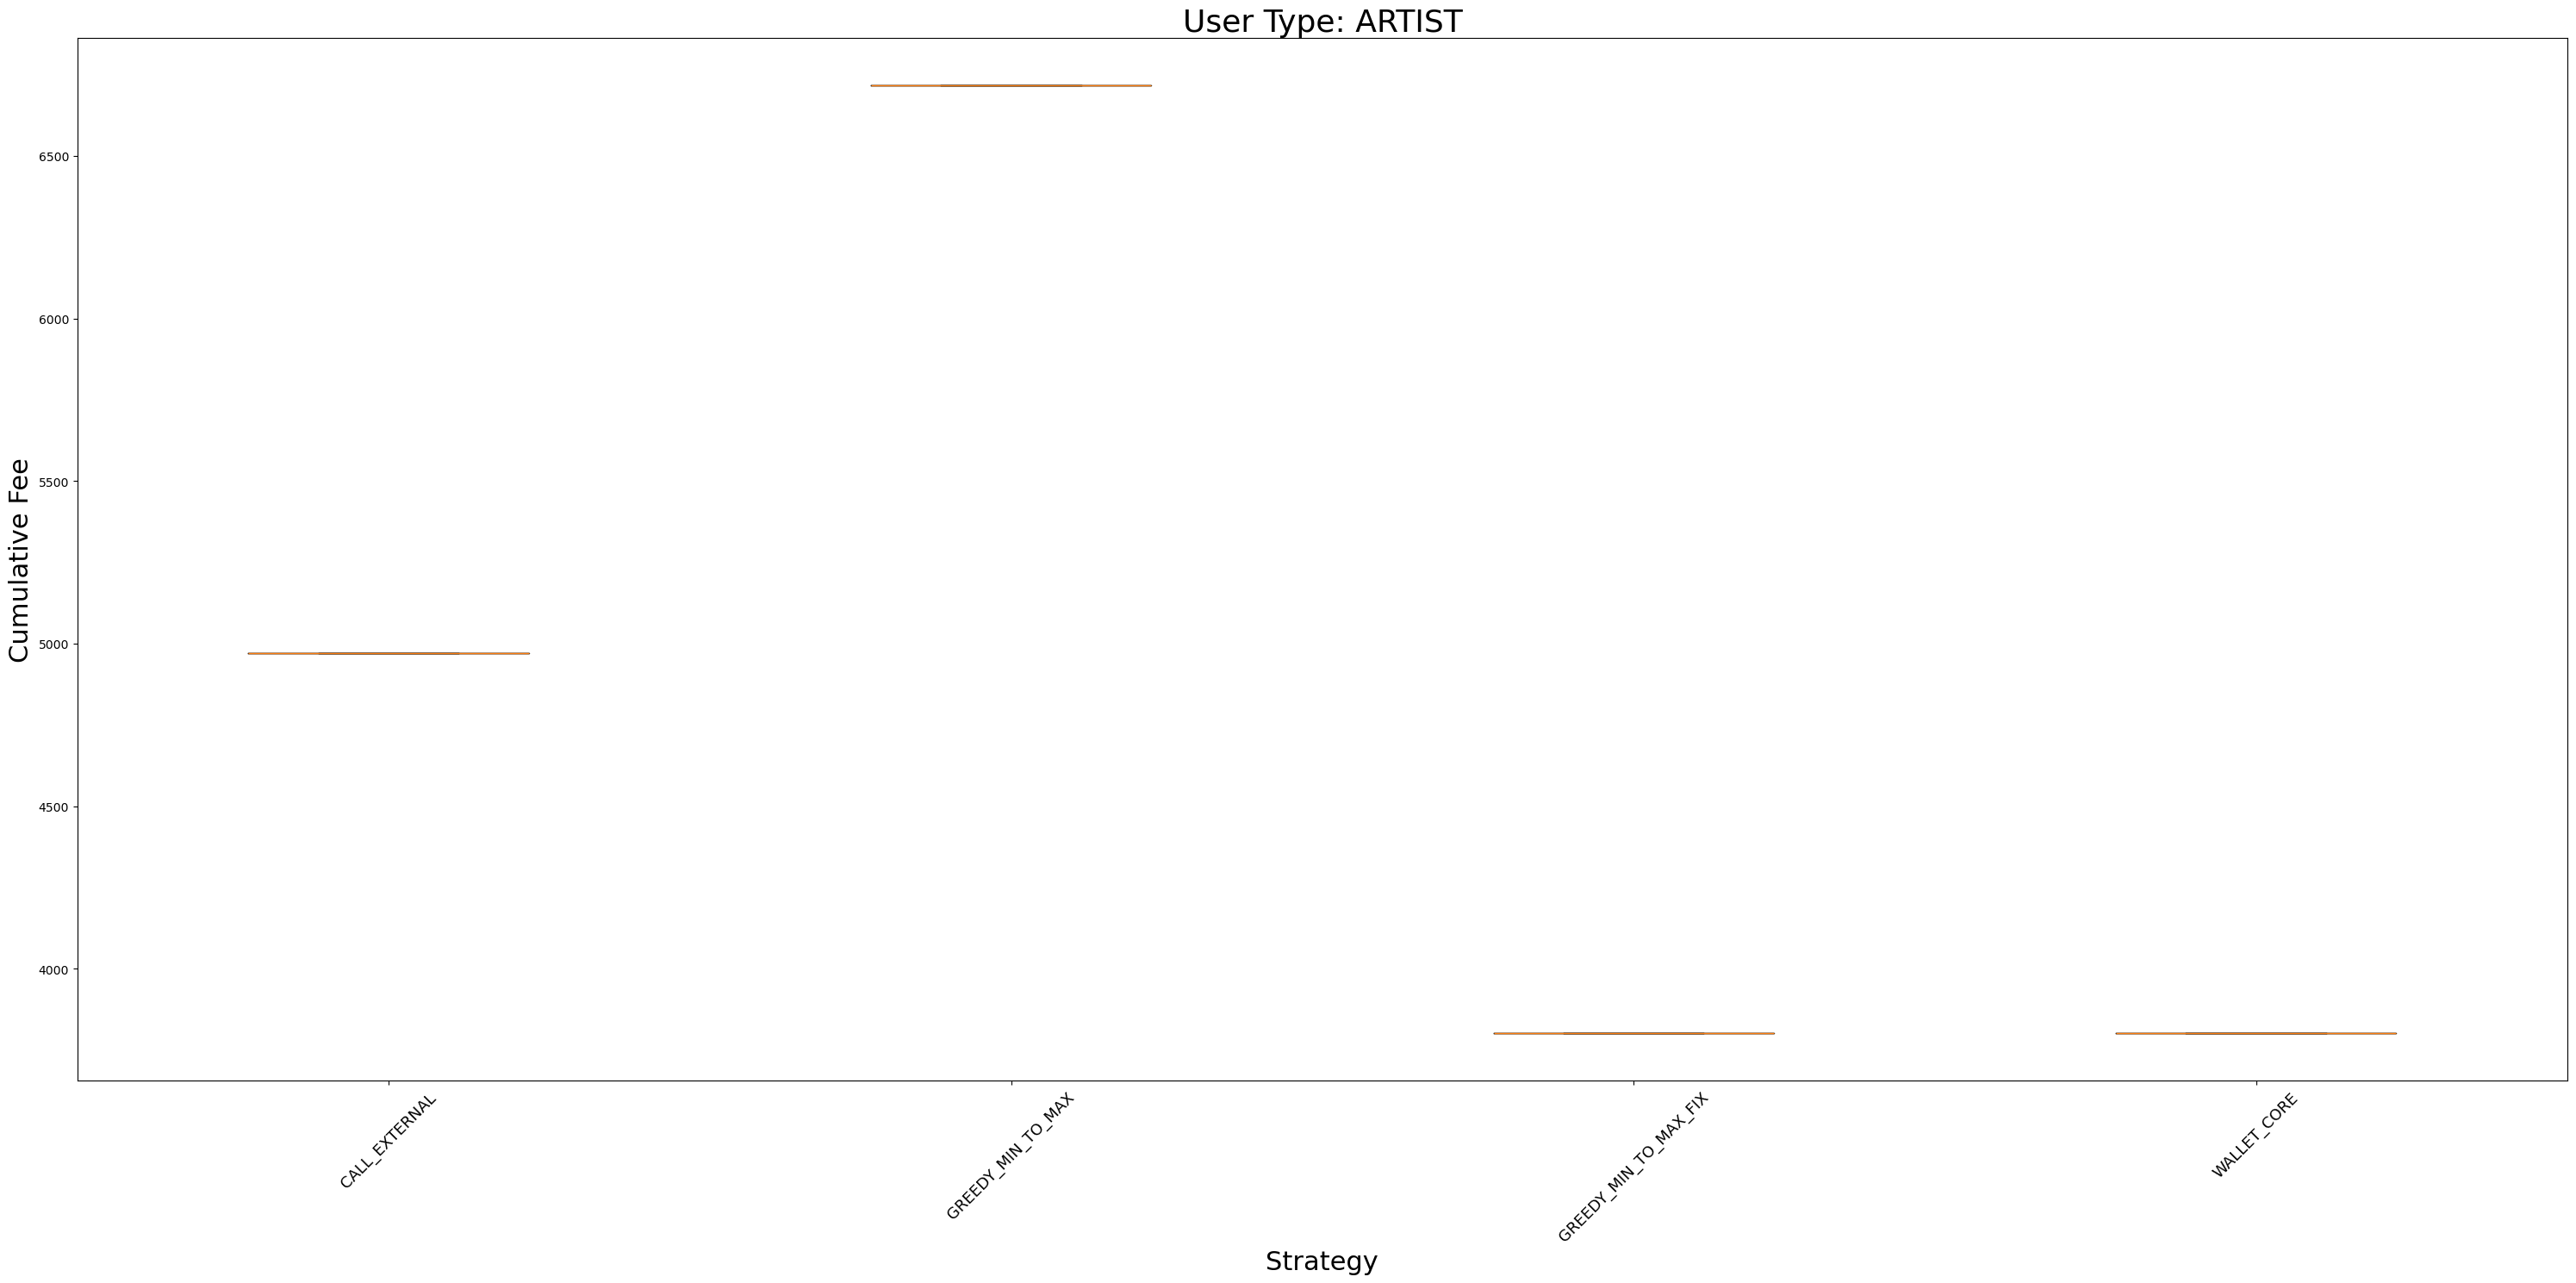

In [4]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(4, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
plt.show()

# Composition of the Fees for each Strategy

/tmp/ipykernel_44686/2398152947.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=True)  # Optionally add `showfliers=False` to hide outliers


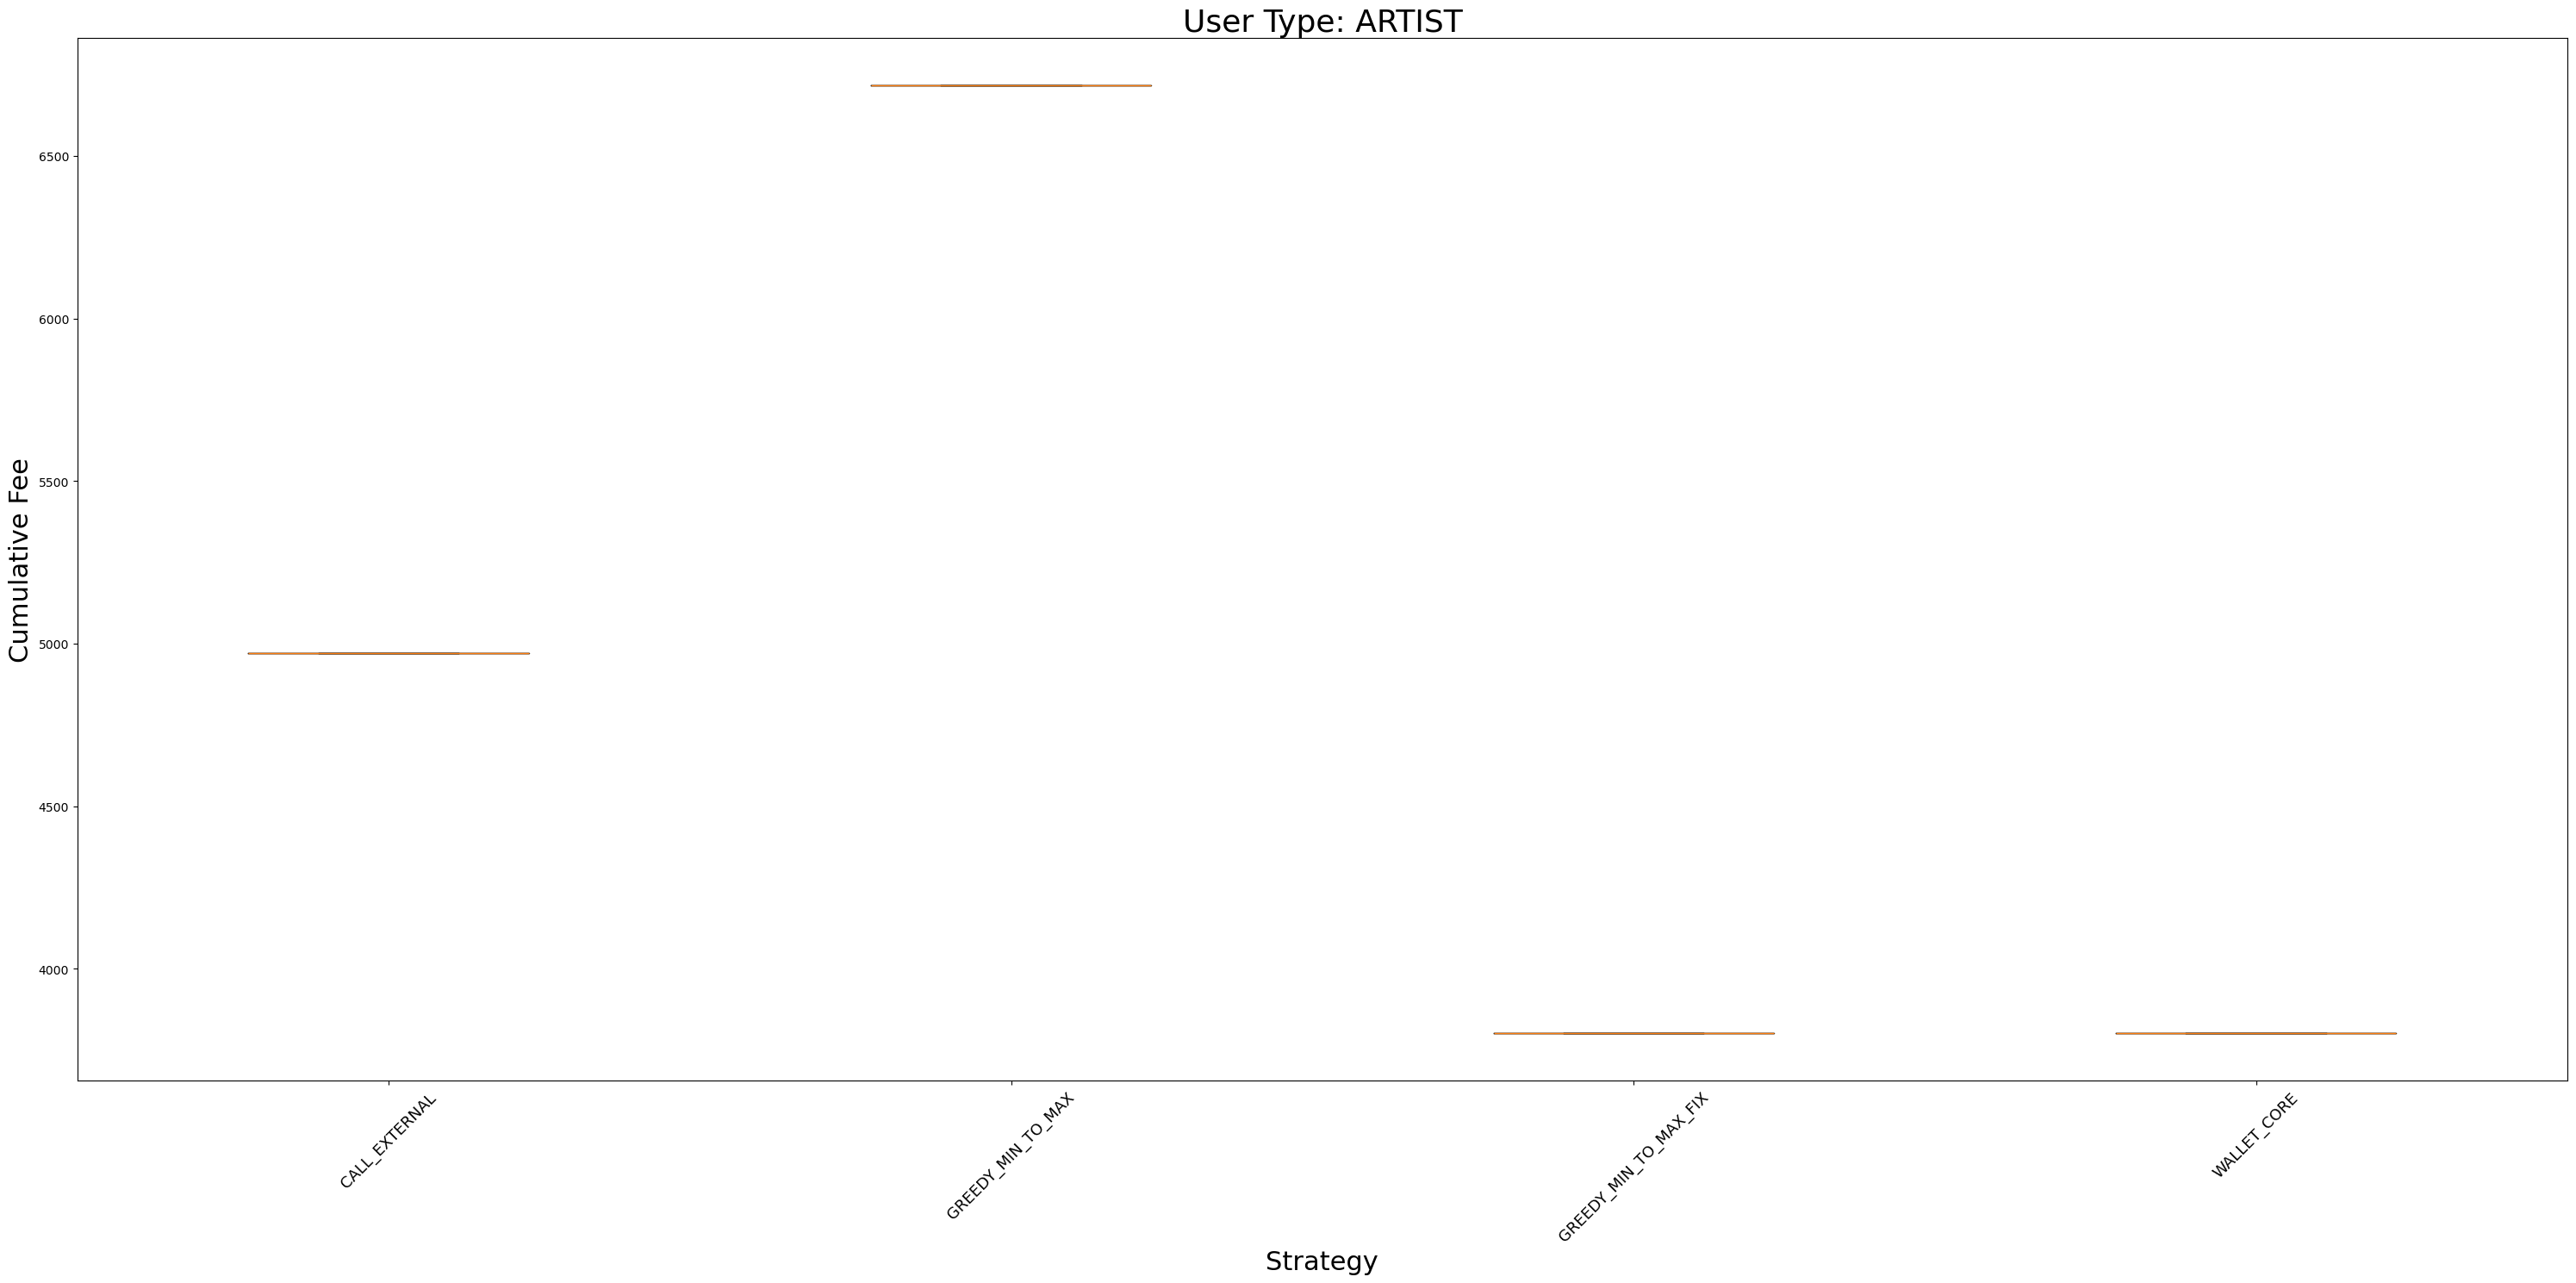

In [5]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(4, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=True)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
plt.show()

In [2]:
from src import util

dfs = util.load_all_dfs()



coins_user_0_strategy_WALLET_CORE.json: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1478/1478 [00:22<00:00, 64.78it/s]


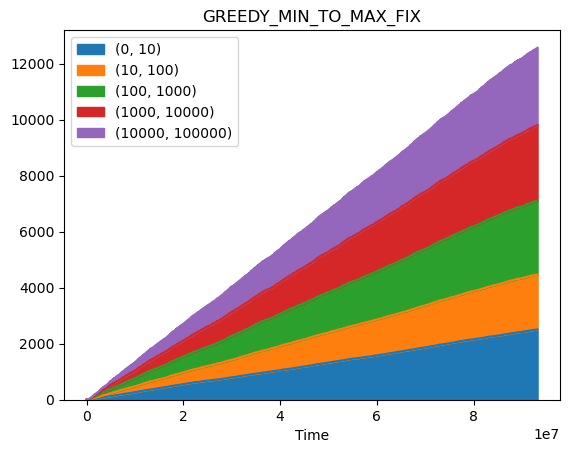

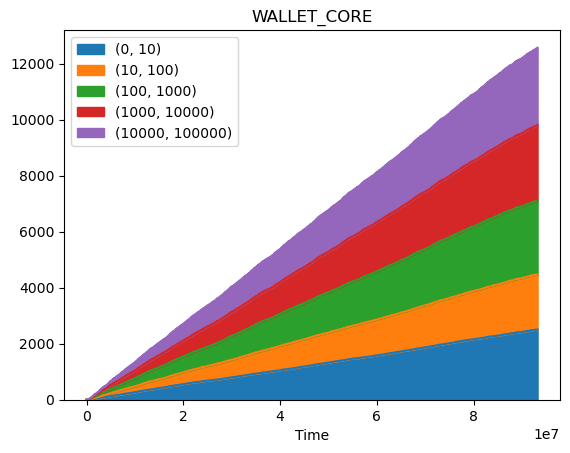

In [3]:
for file_name, user_df in dfs.groupby('FileName'):
    name = file_name.split(".")[0]
    name = name.removeprefix("coins_user_0_strategy_")
    ax = user_df.plot.area(x="Time", title=name)
    fig = ax.get_figure()
    fig.savefig(f"pictures/area-{name}", dpi=300)
    

# Fee Types for each Strategy/(TODO: User)

In [ ]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy', 'Operation'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(4, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=True)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
plt.show()

In [5]:
from src import util
import pandas as pd
import matplotlib.pyplot as plt
json_files = util.match_json_files()

coins_user_0_strategy_GREEDY_MIN_TO_MAX_FIX.json: 100%|███████████████████████████████████████████████████████████████████████████████████| 1478/1478 [00:28<00:00, 52.11it/s]
actions_user_0_strategy_GREEDY_MIN_TO_MAX_FIX.json: 100%|██████████████████████████████████████████████████████████████████████████████| 1414/1414 [00:00<00:00, 69320.86it/s]
actions_user_0_strategy_WALLET_CORE.json: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1414/1414 [00:00<00:00, 75359.86it/s]


In [6]:
from itertools import chain
c_df, a_df = util.load_all_dfs_new(json_files)
c_df = pd.DataFrame(chain.from_iterable(util.load_coin_df(c, f) for f, (c, a) in json_files.items()))
a_df = pd.DataFrame(chain.from_iterable(util.load_action_df(a, f) for f, (c, a) in json_files.items()))
print(c_df)

          Time    Balance  CoinCount                               FileName
0           -1          0          0            user_0_strategy_WALLET_CORE
1            0          0          0            user_0_strategy_WALLET_CORE
2        86400          0          0            user_0_strategy_WALLET_CORE
3       172800          0          0            user_0_strategy_WALLET_CORE
4       259200          0          0            user_0_strategy_WALLET_CORE
...        ...        ...        ...                                    ...
2157  92880000  281429518      13636  user_0_strategy_GREEDY_MIN_TO_MAX_FIX
2158  92966400  283066494      13655  user_0_strategy_GREEDY_MIN_TO_MAX_FIX
2159  93052800  283049335      13661  user_0_strategy_GREEDY_MIN_TO_MAX_FIX
2160  93139200  283024688      13674  user_0_strategy_GREEDY_MIN_TO_MAX_FIX
2161  93225600  283000723      13682  user_0_strategy_GREEDY_MIN_TO_MAX_FIX

[2162 rows x 4 columns]


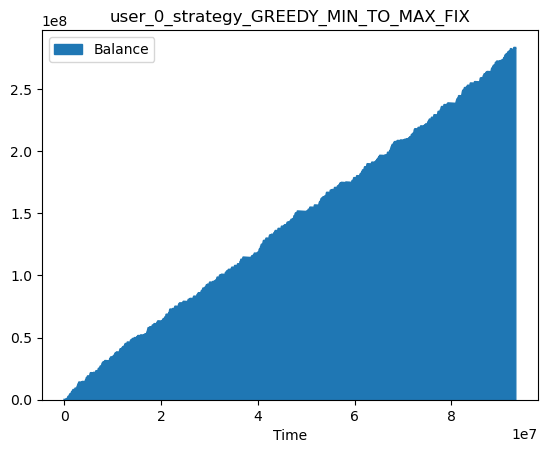

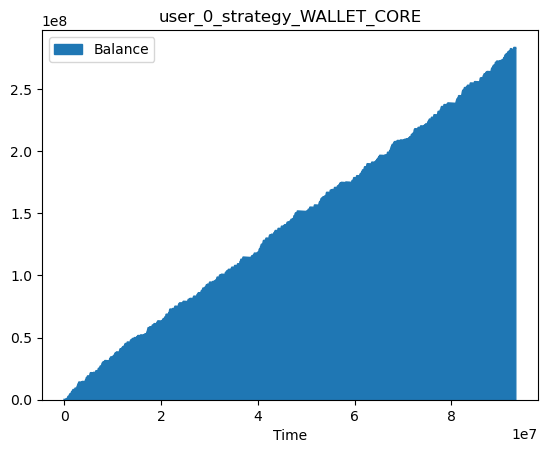

In [7]:
for file_name, user_df in c_df.groupby('FileName'):
    name = file_name.split(".")[0]
    name = name.removeprefix("coins_user_0_strategy_")
    ax = user_df.plot.area(x="Time", y="Balance", title=name)
    fig = ax.get_figure()

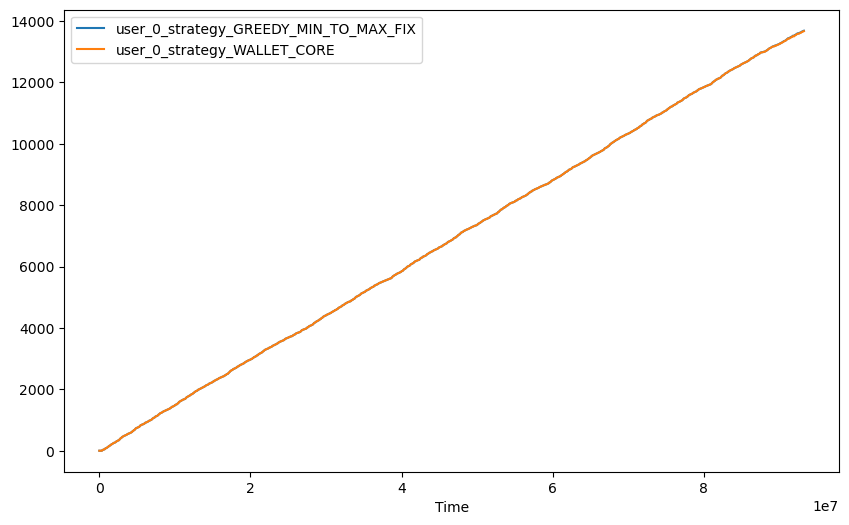

In [8]:
plt.figure(figsize=(10, 6))
c_df.set_index("Time", inplace=True)
ax = c_df.groupby('FileName')["CoinCount"].plot(legend=True)